In [1]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import matplotlib.ticker as ticker
import os

output_folder = '/home/steven/thesis/thesis_config/config/tester/outputs/'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import matplotlib.ticker as ticker


### Function for getting modes and uncertainties
def best_fit(samples,weights) : 
    for i in range(samples.shape[1]):
        name = samples[0,i]
        values = samples[1:,i].astype(float)
        ## Getting the mode
        hist, bin_edges = np.histogram(values,bins=200,weights=weights,density=True)
        bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
        mode = bin_centers[np.argmax(hist)]

        ## Getting the uncertainty using HPDI
        sort = np.argsort(values)
        sorted_values = values[sort]
        sorted_w = weights[sort]
        cdf = np.cumsum(sorted_w)
        intervals = []
        for i in range(len(weights)) :
            target_cdf = cdf[i]+0.68
            if target_cdf>1 :
                break
            target_index = np.argmin(np.abs(cdf-target_cdf))
            interval = sorted_values[target_index] - sorted_values[i]
            intervals.append(interval)
        interval = np.min(intervals)
        uncertainty = interval
        print(f"{name} = {mode} +/- {uncertainty}")

### Function for plotting contour
def plot_contour(samples, weights) :
    names = samples[0]
    samples = samples[1:].astype(float)
    mc = MCSamples(samples=samples, weights=weights, names=names, labels=names)
    for i in range(len(names)-1) :
        g = plots.get_subplot_plotter(subplot_size=7)
        print("contour for om-",names[i+1])
        g.plot_2d(mc,names[0],names[i+1],filled=True, colors=["grey"],clear=False)
        xdata = mc.samples[:, mc.index[names[0]]]
        ydata = mc.samples[:, mc.index[names[i+1]]]
        plt.xlim(xdata.min(),xdata.max())
        # plt.ylim(ydata.min(),ydata.max())
        g.add_legend(["$\Lambda$CDM, linear"])
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))  # increase nbins
        plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
        plt.savefig(f"{i}.pdf")        

<>:47: SyntaxWarning: invalid escape sequence '\L'
<>:47: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_26335/3865684854.py:47: SyntaxWarning: invalid escape sequence '\L'
  g.add_legend(["$\Lambda$CDM, linear"])


<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_26335/3415437523.py:55: SyntaxWarning: invalid escape sequence '\O'
  sample_names = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA","\Omega_ch^2","\Omega_bh^2"]
/tmp/ipykernel_26335/3415437523.py:55: SyntaxWarning: invalid escape sequence '\O'
  sample_names = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA","\Omega_ch^2","\Omega_bh^2"]
/tmp/ipykernel_26335/3415437523.py:58: SyntaxWarning: invalid escape sequence '\O'
  sample_names = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA","\Omega_ch^2","\Omega_bh^2","h"]
/tmp/ipykernel_26335/3415437523.py:58: SyntaxWarning: inv

alpha = 0.3899000574739932 +/- 0.009204889707921084
Sigma_8 (from regression) = 0.689718150594382 +/- 0.005027053798823293
Removed no burn in
contour for om- \sigma_8
contour for om- S_8
contour for om- \Sigma_8
contour for om- IA
contour for om- \Omega_ch^2
contour for om- \Omega_bh^2
contour for om- h

Best-fitting values and uncertainties: 
\Omega_m = 0.12250711743442216 +/- 0.280498544842888
\sigma_8 = 0.6657531581879125 +/- 0.4056797888591894
S_8 = 0.6277908563613892 +/- 0.21565723547251348
\Sigma_8 = 0.6303505375341156 +/- 0.2025051250136941
IA = -2.0809046870903014 +/- 3.6310117398657837
\Omega_ch^2 = 0.024442228910326956 +/- 0.15248896640680332
\Omega_bh^2 = 0.022198218748925042 +/- 0.004223973308671466
h = 0.8094660985285822 +/- 0.11153519534902923


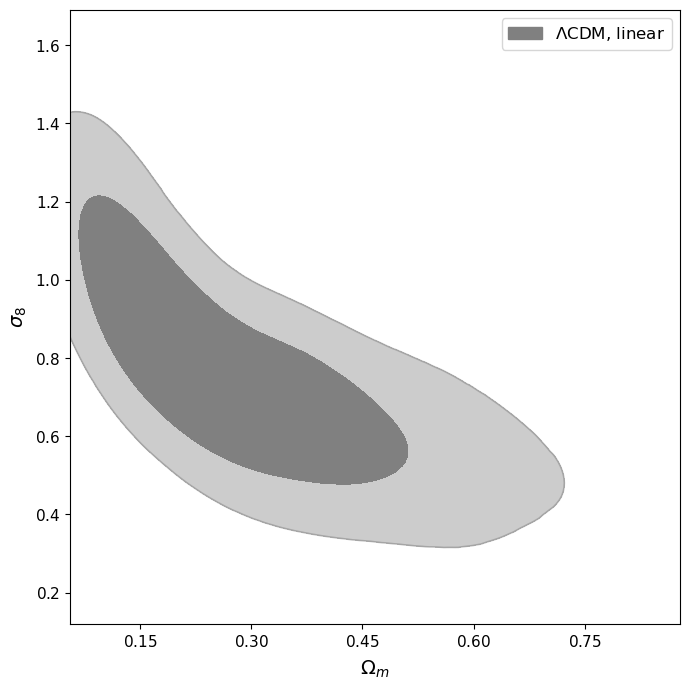

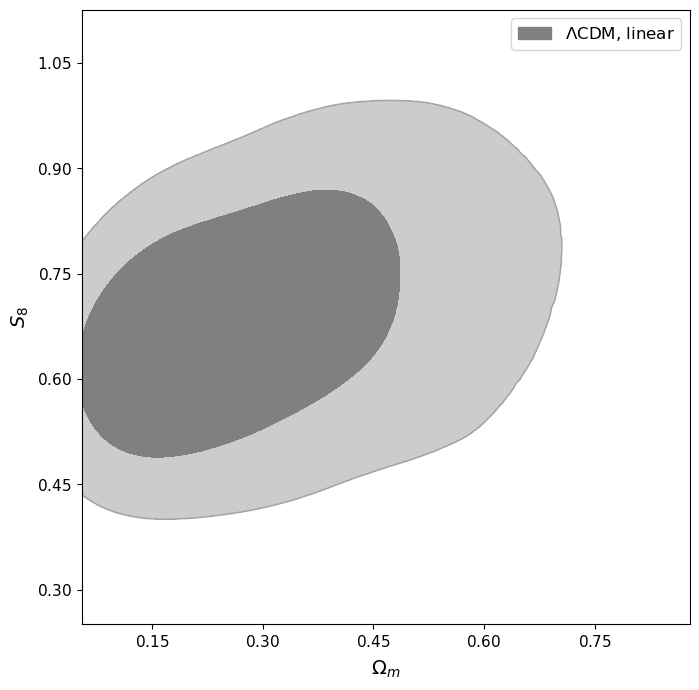

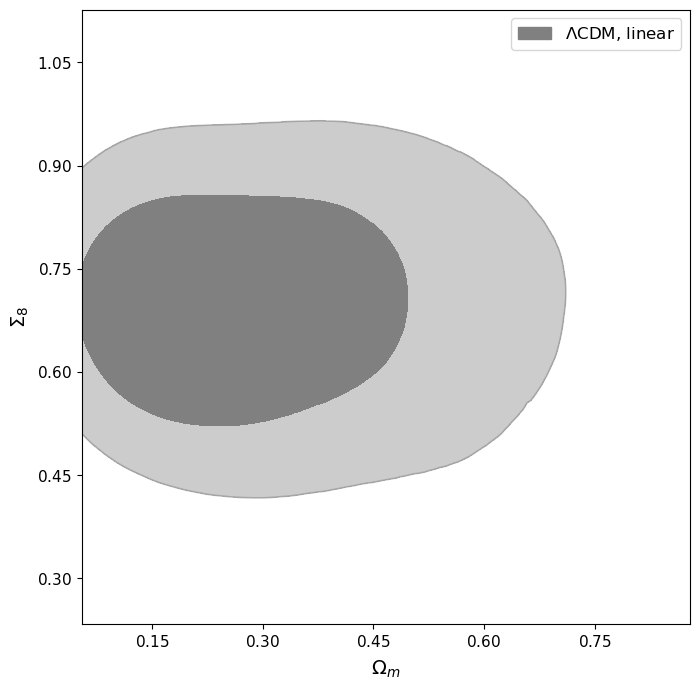

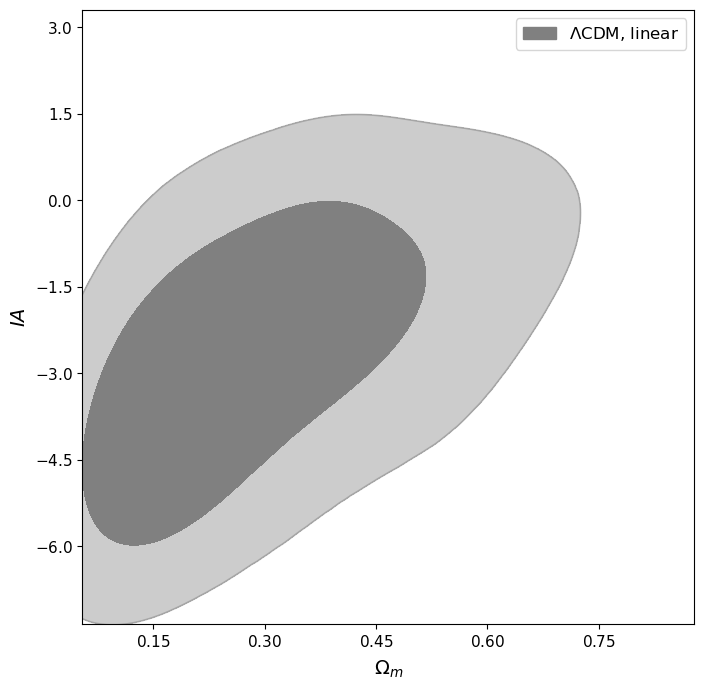

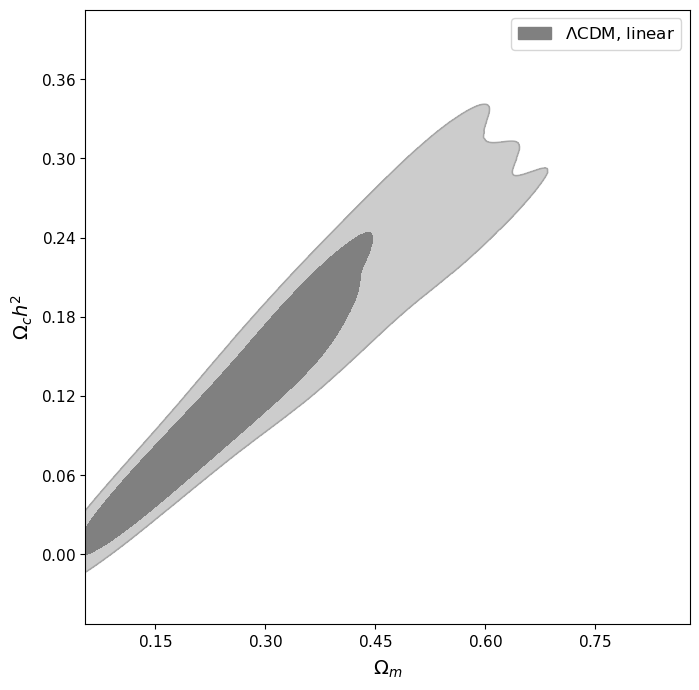

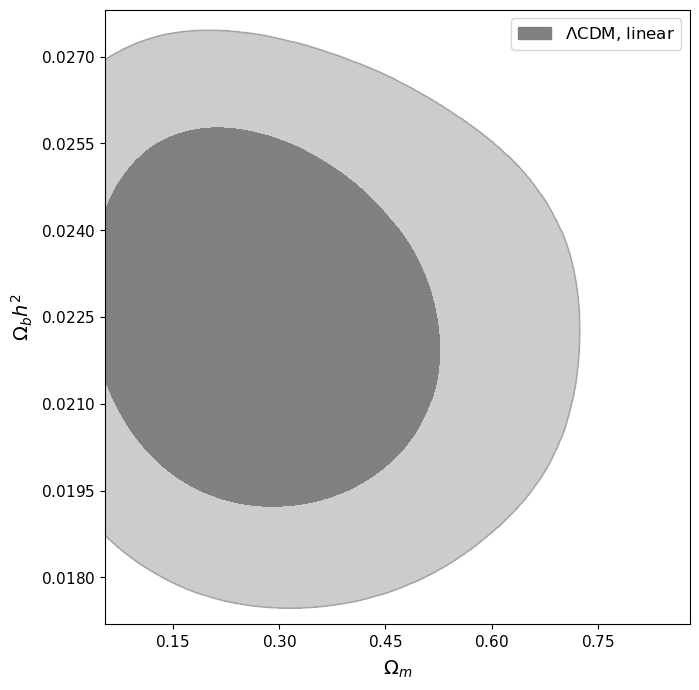

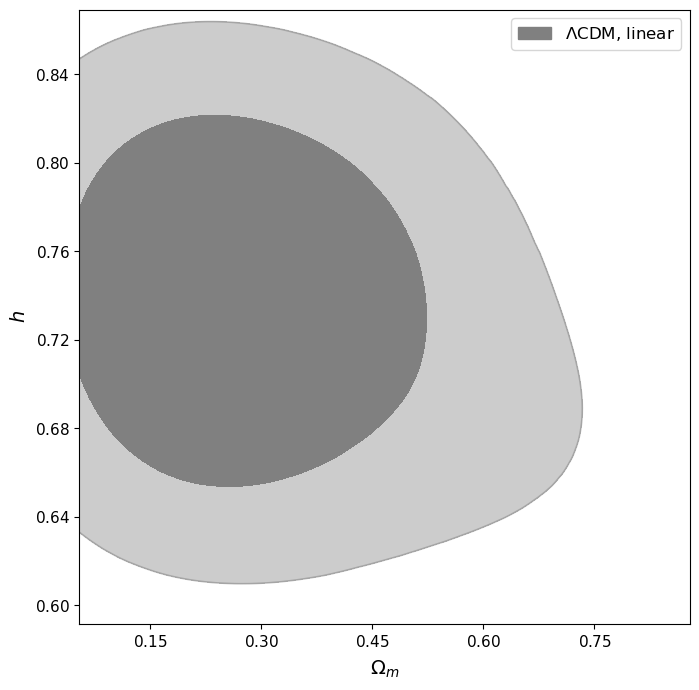

In [3]:
file = os.path.join(output_folder,"output_multinest_kids_lin.txt")
# file = "../outputs/output_multinest_all_datasets.txt"
# file = "../outputs/output_multinest_WL_only.txt"
# file = "../outputs/output_multinest_SN.txt"
# file = "../outputs/output_multinest_SN_BAO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO_Marie.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO_z2.txt"
# file = "../outputs/output_multinest_true.txt"
index_h0 = None
with open(file, "r") as f:
        header = f.readline().strip().split()
        for i,name in enumerate(header) :
            if "omch2" in name :
                index_omch2 = i
            if "ombh2" in name :
                index_ombh2 = i
            if "s_8" in name :
                index_s8 = i
            if "h0" in name :
                index_h0 = i
            if "intrinsic_alignment" in name :
                 index_ia = i

data = np.loadtxt(file)
prior = data[:,-4]
like = data[:,-3]
post = data[:,-2]
w = data[:,-1]
omch2 = data[:,index_omch2]
ombh2 = data[:,index_ombh2]
s8 = data[:,index_s8]
ia = data[:,index_ia]
if index_h0 is None :
    h0 = 0.735
else :
     h0 = data[:,index_h0]
om = (omch2+ombh2)/h0**2
sigma_8 = s8/(om/0.3)**0.5

### Fitting for alpha by performing linear regression : log(sigma_8) = -alpha*log(omega_m/0.3) + c
X = np.log(om/0.3)
Y = np.log(sigma_8)
coeffs, cov = np.polyfit(X,Y,deg=1,cov=True,w=w)
alpha,Sigma_8_reg = coeffs
alpha = -alpha
alpha_err , Sigma_8_reg_err = np.sqrt(np.diag(cov))
print(f"alpha = {alpha} +/- {alpha_err}")
print(f"Sigma_8 (from regression) = {np.exp(Sigma_8_reg)} +/- {Sigma_8_reg_err}")
Sigma_8 = sigma_8*(om/0.3)**alpha

### Get (s8, sigma8, Sigma8)-omega_m contour
if index_h0 is None :
     sample_values = np.vstack([om,sigma_8,s8,Sigma_8,ia,omch2,ombh2]).T
     sample_names = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA","\Omega_ch^2","\Omega_bh^2"]
else : 
    sample_values = np.vstack([om,sigma_8,s8,Sigma_8,ia,omch2,ombh2,h0]).T
    sample_names = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA","\Omega_ch^2","\Omega_bh^2","h"]
samples = np.vstack([sample_names,sample_values])
plot_contour(samples,w)

### Getting the uncertainties for more than one params
print("\nBest-fitting values and uncertainties: ")
best_fit(samples,w)

In [4]:
files = {"kids nl" : "../outputs/output_multinest_true.txt",
         "kids lin" : "../outputs/output_multinest_kids_lin.txt",
         "SN" : "../outputs/output_multinest_SN.txt", 
         "SN+BAO" : "../outputs/output_multinest_SN_BAO.txt", 
         "SN+BAO+QSO" : "../outputs/output_multinest_SN_BAO_QSO.txt",
         "SN+BAO+QSO_z2" : "../outputs/output_multinest_SN_BAO_QSO_z2.txt",
         "Marie" : "../outputs/output_multinest_SN_BAO_QSO_Marie.txt"}
mc = {}
sample_names = {}
sample_values = {}
for key in files :
    index_h0 = None
    file = files[key]
    with open(file, "r") as f:
            header = f.readline().strip().split()
            for i,name in enumerate(header) :
                if "omch2" in name :
                    index_omch2 = i
                if "ombh2" in name :
                    index_ombh2 = i
                if "s_8" in name :
                    index_s8 = i
                if "h0" in name :
                    index_h0 = i
                if "intrinsic_alignment" in name :
                    index_ia = i
    data = np.loadtxt(file)
    like = data[:,-3]
    post = data[:,-2]
    w = data[:,-1]
    omch2 = data[:,index_omch2]
    ombh2 = data[:,index_ombh2]
    s8 = data[:,index_s8]
    ia = data[:,index_ia]
    if index_h0 is None :
        h0 = 0.735
    else :
        h0 = data[:,index_h0]
    om = (omch2+ombh2)/h0**2
    sigma_8 = s8/(om/0.3)**0.5

    X = np.log(om/0.3)
    Y = np.log(sigma_8)
    coeffs, cov = np.polyfit(X,Y,deg=1,cov=True,w=w)
    alpha,Sigma_8_reg = coeffs
    alpha = -alpha
    alpha_err , Sigma_8_reg_err = np.sqrt(np.diag(cov))
    print(f"alpha = {alpha} +/- {alpha_err}")
    print(f"Sigma_8 (from regression) = {np.exp(Sigma_8_reg_err)} +/- {Sigma_8_reg_err}")
    Sigma_8 = sigma_8*(om/0.3)**alpha

    sample_values[key] = np.vstack([om,sigma_8,s8,Sigma_8,ia]).T
    sample_names[key] = ["\\Omega_m","\\sigma_8","S_8","\\Sigma_8","IA"]

    mc[key] = MCSamples(samples=sample_values[key], weights=w, names=sample_names[key], labels=sample_names[key])

alpha = 0.5582357867471813 +/- 0.002206596382119732
Sigma_8 (from regression) = 1.0006513235899543 +/- 0.0006511115708019609
Removed no burn in
alpha = 0.3899000574739932 +/- 0.009204889707921084
Sigma_8 (from regression) = 1.005039710633747 +/- 0.005027053798823293
Removed no burn in
alpha = 0.5204490903242381 +/- 0.017282935132715217
Sigma_8 (from regression) = 1.0054734965860135 +/- 0.005458571440627314
Removed no burn in
alpha = 0.6241742978984821 +/- 0.014080477268046943
Sigma_8 (from regression) = 1.0050857767349781 +/- 0.00507288785398921
Removed no burn in
alpha = 0.9061654845131155 +/- 0.01424168994343485
Sigma_8 (from regression) = 1.0054671946982494 +/- 0.00545230383881152
Removed no burn in
alpha = 0.700163312298622 +/- 0.015995229148016585
Sigma_8 (from regression) = 1.0056283398162706 +/- 0.00561255989388248
Removed no burn in
alpha = 0.41310226200390726 +/- 0.22633029064038296
Sigma_8 (from regression) = 1.0355774970383442 +/- 0.034959239263971674
Removed no burn in


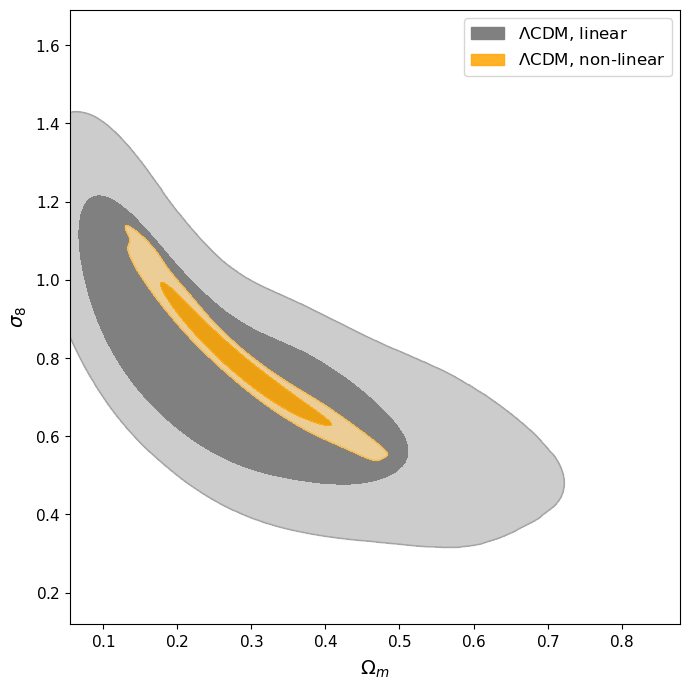

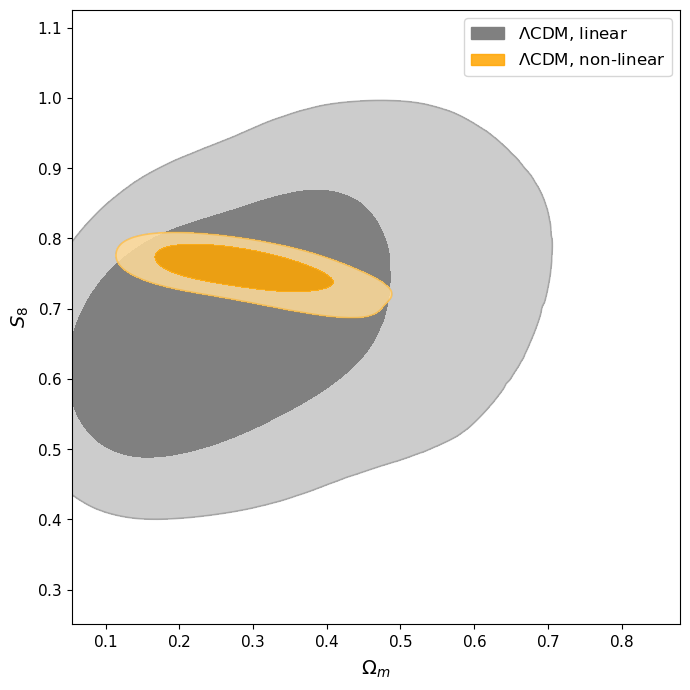

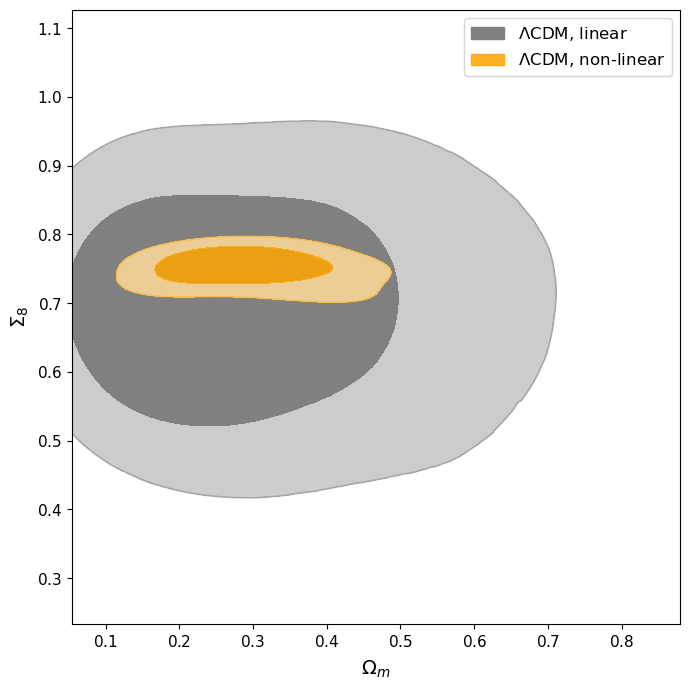

In [5]:
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=7, ratio = 1)
    # g.settings.alpha_filled_add=0.7
    # g.settings.solid_contour_palefactor = 0.7
    # g.settings.alpha_factor_contour_lines = 1
    g.plot_2d([mc["kids lin"],mc["kids nl"]],sample_names["SN"][0], sample_names["SN"][i], colors=["grey", "orange"], filled = [True,True, True, True])
    g.add_legend([r"$\Lambda$CDM, linear",r"$\Lambda$CDM, non-linear"])
    xdata = mc["kids lin"].samples[:, mc["kids lin"].index[sample_names["kids lin"][0]]]
    ydata = mc["kids lin"].samples[:, mc["kids lin"].index[sample_names["kids lin"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    # plt.ylim(ydata.min(),ydata.max())
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=9))  # increase nbins
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=9))
    plt.savefig(f"{i}.pdf")

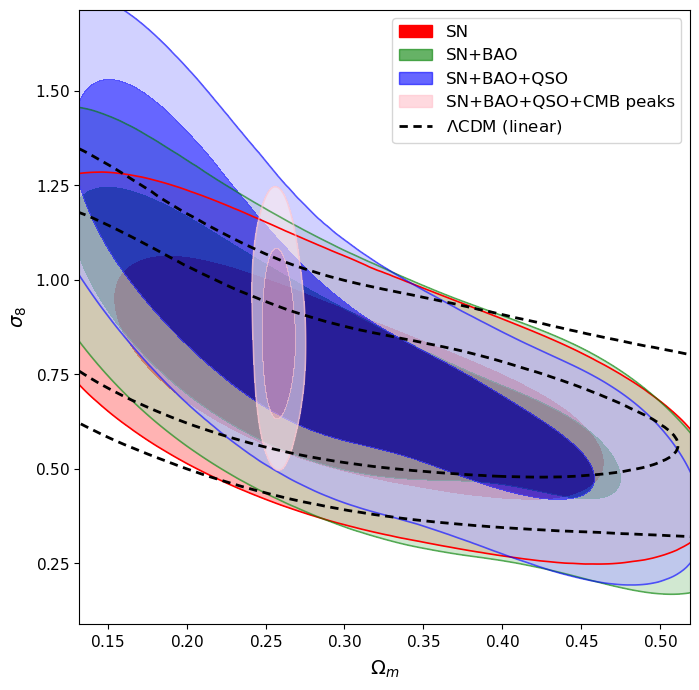

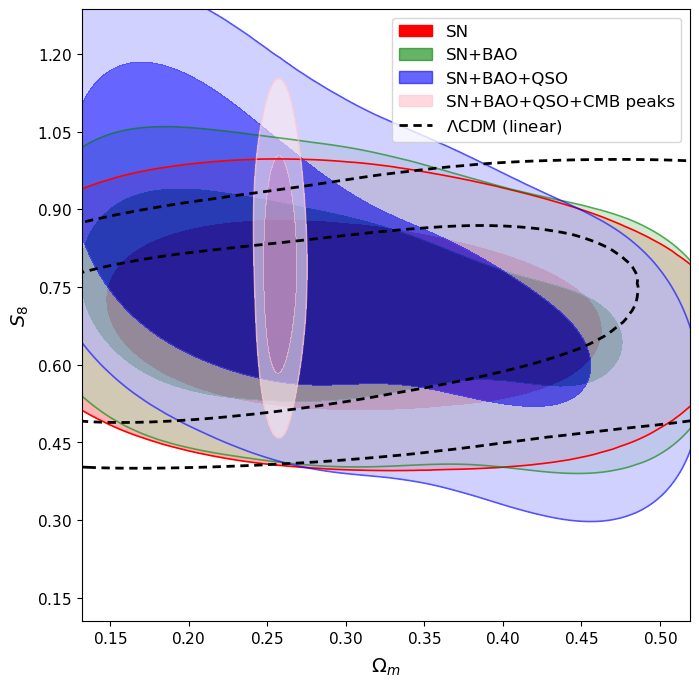

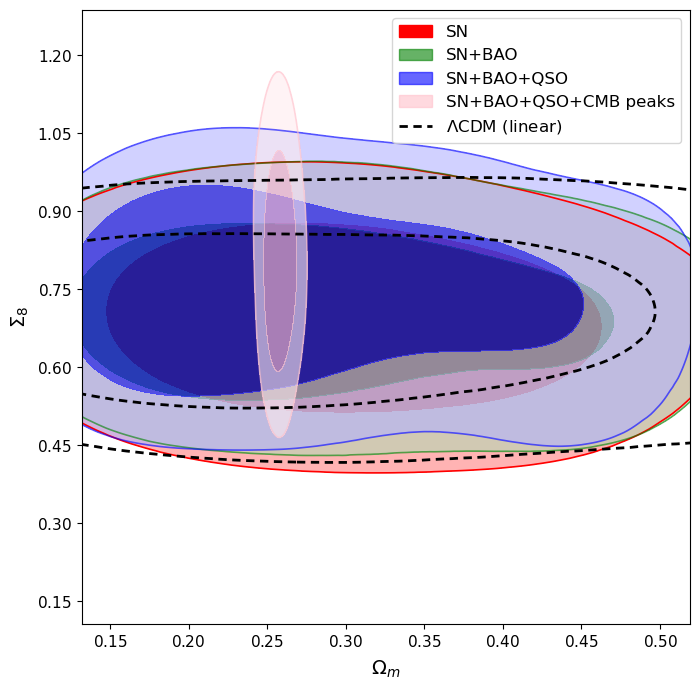

In [6]:
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=7, ratio = 1)
    g.settings.alpha_filled_add=0.6
    g.settings.solid_contour_palefactor = 0.7
    g.settings.alpha_factor_contour_lines = 1
    g.plot_2d([mc["SN"],mc["SN+BAO"],mc["SN+BAO+QSO"],mc["Marie"]],sample_names["SN"][0], sample_names["SN"][i], colors=["red", "green", "blue", "pink"], filled = [True,True, True, True])
    g.add_2d_contours(mc["kids lin"],sample_names["SN"][0], sample_names["SN"][i], ls="--", color="black")
    g.add_legend(["SN", "SN+BAO", "SN+BAO+QSO", "SN+BAO+QSO+CMB peaks",r"$\Lambda$CDM (linear)"])
    xdata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][0]]]
    ydata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    plt.ylim(ydata.min(),ydata.max())
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))  # increase nbins
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
    plt.savefig(f"{i}.pdf")

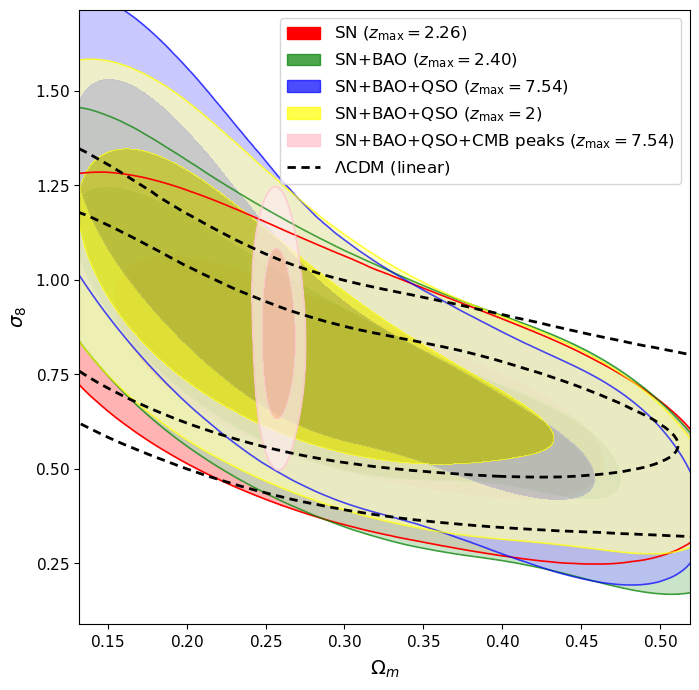

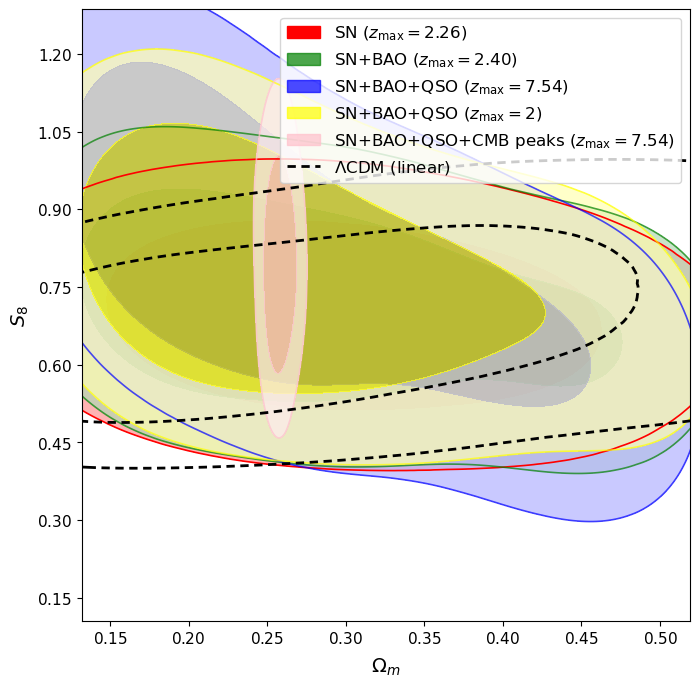

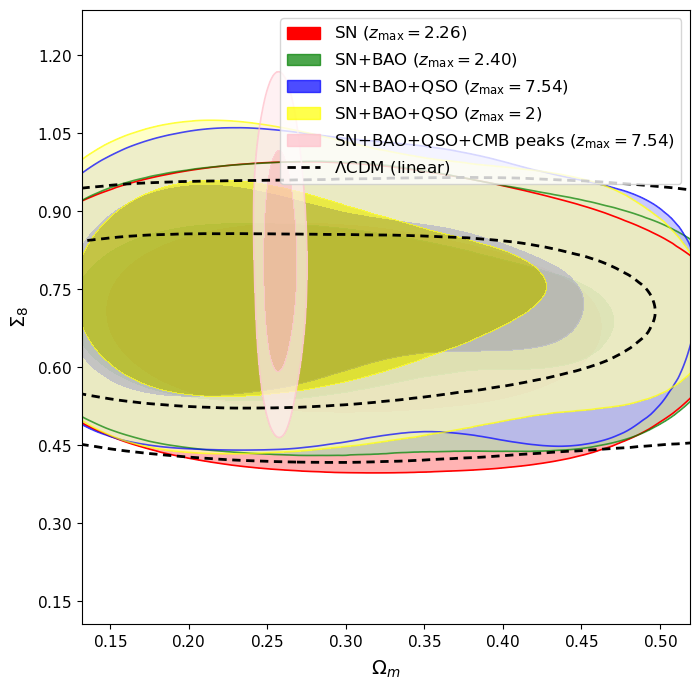

In [7]:
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=7, ratio = 1)
    g.settings.alpha_filled_add=0.7
    g.settings.solid_contour_palefactor = 0.7
    g.settings.alpha_factor_contour_lines = 1
    g.plot_2d([mc["SN"],mc["SN+BAO"],mc["SN+BAO+QSO"],mc["SN+BAO+QSO_z2"],mc["Marie"]],sample_names["SN"][0], sample_names["SN"][i], colors=["red", "green", "blue", "yellow", "pink"], filled = [True,True, True, True, True])
    # g.add_2d_contours(mc["SN+BAO+QSO_z2"],
    #                   sample_names["SN"][0], sample_names["SN"][i],
    #                   color="yellow",  # pick a distinct color
    #                   filled=True,     # filled region
    #                   alpha=0.7)       # higher opacity than the others
    g.add_2d_contours(mc["kids lin"],sample_names["SN"][0], sample_names["SN"][i], ls="--", color="black")
    g.add_legend([r"SN ($z_\max=2.26$)", r"SN+BAO ($z_\max=2.40$)", r"SN+BAO+QSO ($z_\max=7.54$)", r"SN+BAO+QSO ($z_\max=2$)", r"SN+BAO+QSO+CMB peaks ($z_\max=7.54$)",r"$\Lambda$CDM (linear)"])
    xdata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][0]]]
    ydata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    plt.ylim(ydata.min(),ydata.max())
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))  # increase nbins
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
    plt.savefig(f"{i}.pdf")

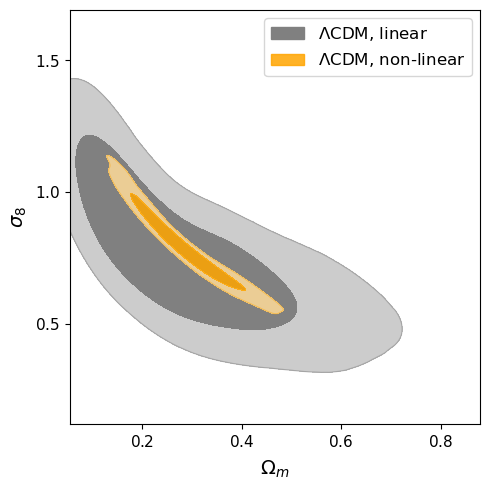

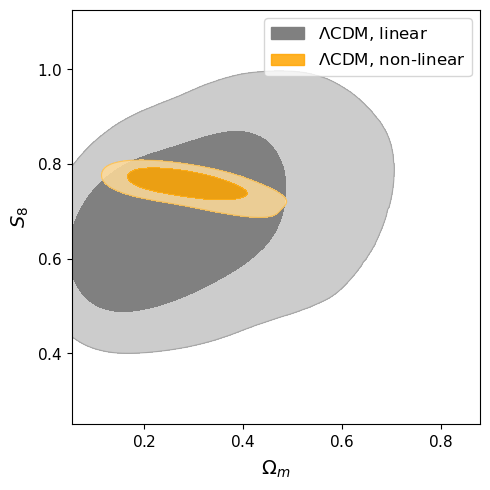

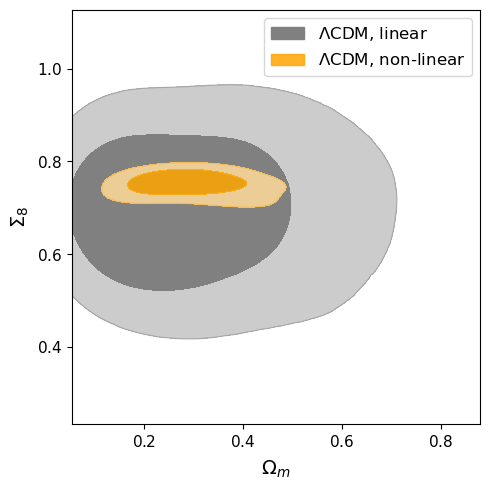

In [12]:
for i in range(1,4):
    g = plots.get_single_plotter(width_inch=5, ratio = 1)
    g.plot_2d([mc["kids lin"],mc["kids nl"]],sample_names["kids lin"][0], sample_names["kids nl"][i], colors=["grey", "orange"], filled = True)
    g.add_legend([r"$\Lambda$CDM, linear",r"$\Lambda$CDM, non-linear"])
    xdata = mc["kids lin"].samples[:, mc["kids lin"].index[sample_names["kids lin"][0]]]
    ydata = mc["kids lin"].samples[:, mc["kids lin"].index[sample_names["kids lin"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    # plt.ylim(ydata.min(),ydata.max())
    plt.savefig(f"{i}.pdf")

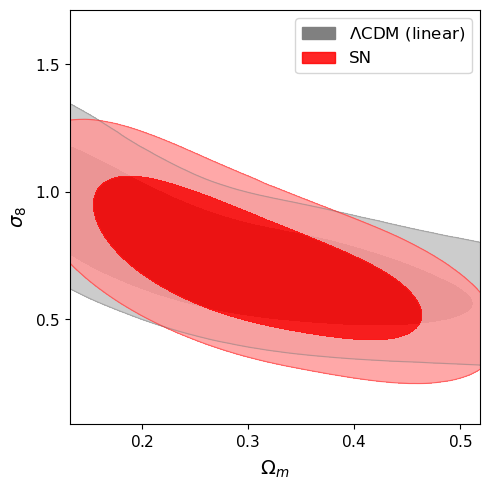

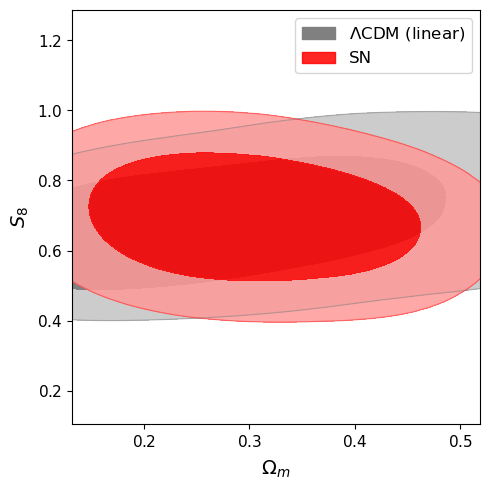

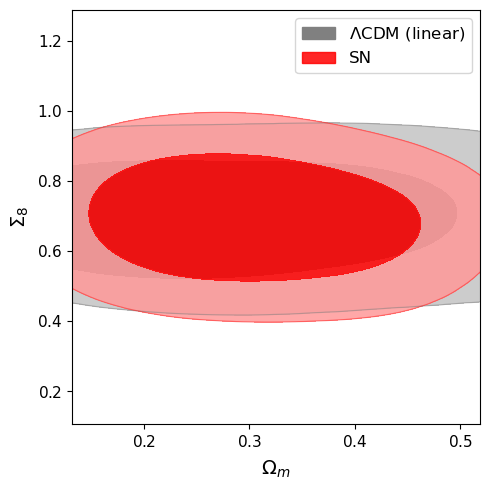

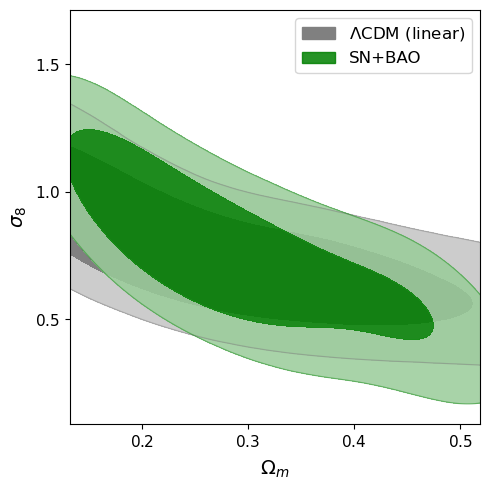

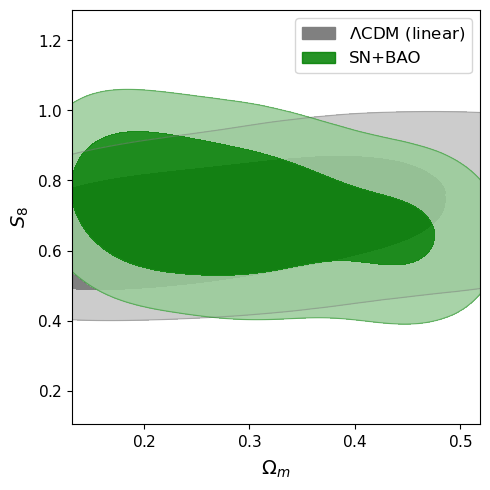

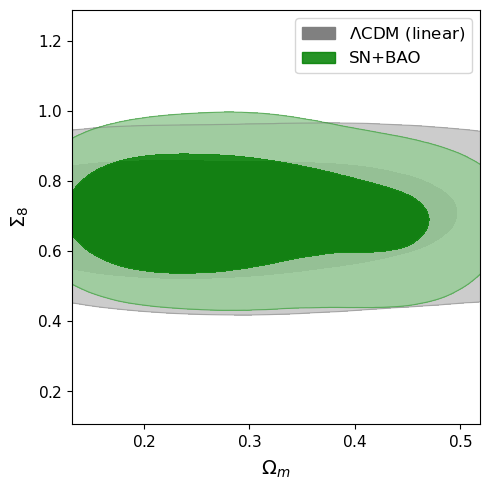

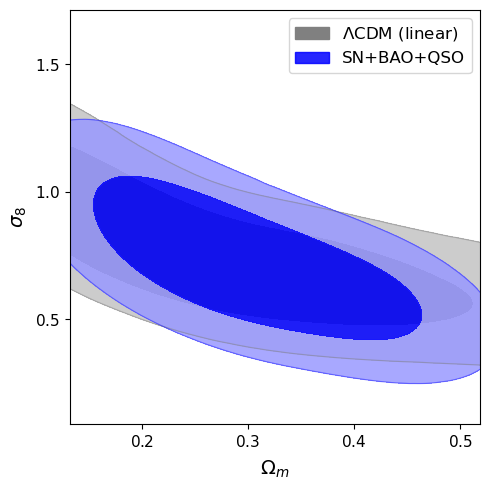

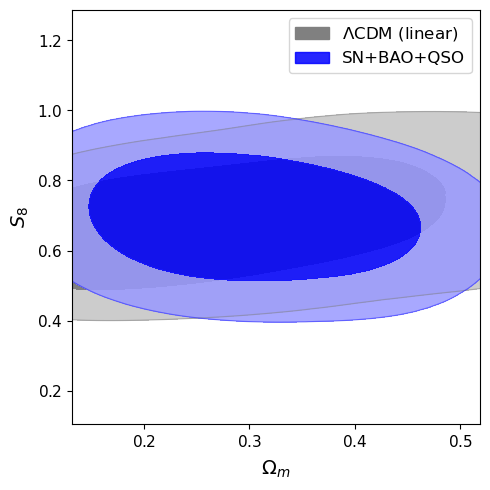

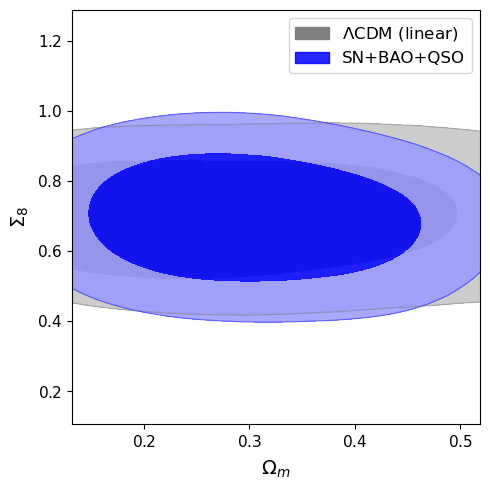

In [18]:
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=5, ratio = 1)
    g.plot_2d([mc["kids lin"],mc["SN"]],sample_names["SN"][0], sample_names["SN"][i], colors=["grey", "red"], filled = True)
    g.add_legend([r"$\Lambda$CDM (linear)","SN"])
    xdata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][0]]]
    ydata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    plt.ylim(ydata.min(),ydata.max())
    plt.savefig(f"{i}.pdf")
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=5, ratio = 1)
    g.plot_2d([mc["kids lin"],mc["SN+BAO"]],sample_names["SN"][0], sample_names["SN"][i], colors=["grey", "green"], filled = True)
    g.add_legend([r"$\Lambda$CDM (linear)","SN+BAO"])
    xdata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][0]]]
    ydata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    plt.ylim(ydata.min(),ydata.max())
    plt.savefig(f"{i}.pdf")
for i in range(1,4) :
    g = plots.get_single_plotter(width_inch=5, ratio = 1)
    g.plot_2d([mc["kids lin"],mc["SN"]],sample_names["SN+BAO+QSO"][0], sample_names["SN"][i], colors=["grey", "blue"], filled = True)
    g.add_legend([r"$\Lambda$CDM (linear)","SN+BAO+QSO"])
    xdata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][0]]]
    ydata = mc["SN"].samples[:, mc["SN"].index[sample_names["SN"][i]]]
    plt.xlim(xdata.min(),xdata.max())
    plt.ylim(ydata.min(),ydata.max())
    plt.savefig(f"{i}.pdf")

In [5]:
## Bestfit of the coefficients with errors
file = "../outputs/output_multinest_WL_KIDS_VALUES.txt"
# file = "../outputs/output_multinest_WL_only_correct.txt"
# file = "../outputs/output_multinest_kids_lin.txt"
# file = "../outputs/output_multinest_all_datasets.txt"
# file = "../outputs/output_multinest_SN.txt"
# file = "../outputs/output_multinest_SN_BAO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO_Marie.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO_z2.txt"
# file = "../outputs/output_multinest_true.txt"
file = np.loadtxt(file)
w = file[:,-1]
c0 = file[:,0]
c1 = file[:,1]
c2 = file[:,2]
c3 = file[:,3]
ia = file[:,5]

sample_values = np.vstack([c0,c1,c2,c3,ia]).T
sample_names = ["c_0","c_1","c_2","c_3","ia"]

# sample_values = np.vstack([c0,c1,c2]).T
# sample_names = ["c_0","c_1","c_2"]

# sample_values = np.vstack([c0,c1]).T
# sample_names = ["c_0","c_1"]

samples = np.vstack([sample_names,sample_values])
best_fit(samples,w)

c_0 = 1.4166690600528997 +/- 2.5173219932471143
c_1 = 0.09674511238932615 +/- 0.6952156513254726
c_2 = 0.025517857074737527 +/- 0.4576394995596407
c_3 = 0.0871104557764068 +/- 0.6052567547078322
ia = 0.3440466965413296 +/- 1.8655639267103652


In [8]:
## Bestfit of the coefficients with errors
output = np.loadtxt("../outputs/output_multinest_SN_BAO_QSO_Marie.txt")
output = np.loadtxt("../outputs/output_multinest_SN_BAO_QSO_z2.txt")
w = output[:,-1]
c0 = output[:,-6]
c1 = output[:,-5]

sample_values = np.vstack([c0,c1]).T
sample_names = ["c_0","c_1"]
samples = np.vstack([sample_names,sample_values])
best_fit(samples,w)

c_0 = 95.06028747202956 +/- 1.5902442359788438
c_1 = 370.12624756391654 +/- 1.7494963159242616


In [9]:
path = "../../../inputs/"
uncorr_c = np.array([95.06028747202956,370.12624756391654])
uncorr_err = np.array([1.5902442359788438, 1.7494963159242616])
cov_sn_bao_qso = np.loadtxt(path+"inv_fisher_matrix_sn_bao_qso.txt")

L = np.linalg.cholesky(cov_sn_bao_qso)
corr_c = L@uncorr_c
corr_err = L@uncorr_err
print(corr_c, corr_err)

[ 1.06161106 -0.22885874] [ 0.01775948 -0.01206291]


In [27]:
# Calculating p-value

file = "../outputs/output_multinest_kids_lin.txt"
# file = "../outputs/output_multinest_all_datasets.txt"
# file = "../outputs/output_multinest_SN.txt"
# file = "../outputs/output_multinest_SN_BAO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO.txt"
# file = "../outputs/output_multinest_SN_BAO_QSO_Marie.txt"
file = "../outputs/output_multinest_true.txt"
index_h0 = None
with open(file, "r") as f:
        header = f.readline().strip().split()
        for i,name in enumerate(header) :
            if "omch2" in name :
                index_omch2 = i
            if "ombh2" in name :
                index_ombh2 = i
            if "s_8" in name :
                index_s8 = i
            if "h0" in name :
                index_h0 = i
            if "intrinsic_alignment" in name :
                 index_ia = i

data = np.loadtxt(file)
like = data[:,-3]
post = data[:,-2]
w = data[:,-1]
omch2 = data[:,index_omch2]
ombh2 = data[:,index_ombh2]
s8 = data[:,index_s8]
ia = data[:,index_ia]

larger_indices = np.where(ia>0)
lower_indices = np.where(ia<0)
larger_prob = np.sum(w[larger_indices])/np.sum(w)
lower_prob = np.sum(w[lower_indices])/np.sum(w)
pval = min(larger_prob,lower_prob)*2
print(pval)


0.36281730903855614
